In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install yfinance
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install tensorflow
!pip install plotly
!pip install mplfinance
!pip install textblob
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.3 MB/s eta 0:00:00


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("All Libraries Installed Successfully")

All Libraries Installed Successfully


In [2]:
import yfinance as yf
import pandas as pd

# Download stock data
stock_data = yf.download(
    "RELIANCE.NS",
    start="2015-01-01",
    end="2025-01-01"
)

# Show first 5 rows
print(stock_data.head())

/tmp/ipykernel_479/1329582058.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2015-01-01  189.999802  190.877155  189.090351  189.657431     2963643
2015-01-02  189.496948  191.743828  189.229471  190.042616     7331366
2015-01-05  187.421249  190.641775  187.046767  189.379239    10103941
2015-01-06  178.915253  186.811408  178.037899  186.169449    18627980
2015-01-07  182.809814  183.772761  179.107830  179.129229    20720312


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
stock_data.to_csv("/content/drive/MyDrive/StockMarketPrediction/dataset/reliance_stock_data.csv")

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [6]:
import pandas as pd

# Load dataset
data = pd.read_csv("/content/drive/MyDrive/StockMarketPrediction/dataset/reliance_stock_data.csv")

# Show first 5 rows
print(data.head())

        Price               Close                High                 Low  \
0      Ticker         RELIANCE.NS         RELIANCE.NS         RELIANCE.NS   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-01   189.9998016357422  190.87715534273178   189.0903506676063   
3  2015-01-02   189.4969482421875  191.74382815812206  189.22947104058622   
4  2015-01-05  187.42124938964844  190.64177456827719  187.04676706013433   

                 Open       Volume  
0         RELIANCE.NS  RELIANCE.NS  
1                 NaN          NaN  
2  189.65743085018167      2963643  
3  190.04261601795088      7331366  
4   189.3792394487279     10103941  


In [7]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2469 non-null   object
 1   Close   2468 non-null   object
 2   High    2468 non-null   object
 3   Low     2468 non-null   object
 4   Open    2468 non-null   object
 5   Volume  2468 non-null   object
dtypes: object(6)
memory usage: 115.9+ KB
None


In [8]:
print(data.isnull().sum())

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


In [12]:
print(data.columns.tolist())

['Price', 'Close', 'High', 'Low', 'Open', 'Volume']


In [13]:
data.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

print(data.head())

         Date               Close                High                 Low  \
0      Ticker         RELIANCE.NS         RELIANCE.NS         RELIANCE.NS   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-01   189.9998016357422  190.87715534273178   189.0903506676063   
3  2015-01-02   189.4969482421875  191.74382815812206  189.22947104058622   
4  2015-01-05  187.42124938964844  190.64177456827719  187.04676706013433   

                 Open       Volume  
0         RELIANCE.NS  RELIANCE.NS  
1                 NaN          NaN  
2  189.65743085018167      2963643  
3  190.04261601795088      7331366  
4   189.3792394487279     10103941  


Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


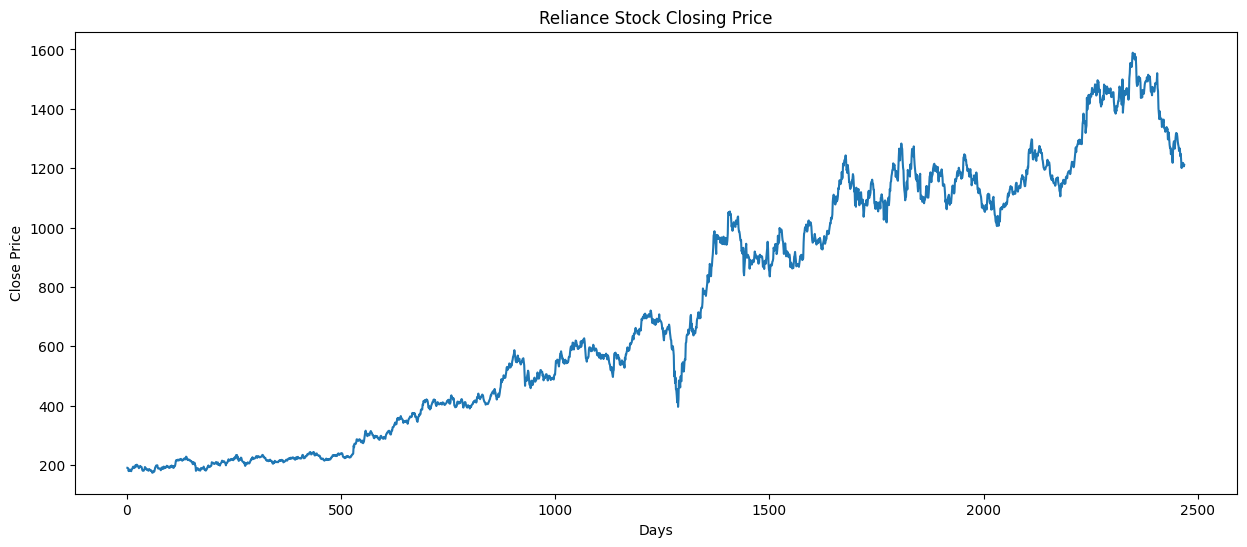

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload dataset
data = pd.read_csv("/content/drive/MyDrive/StockMarketPrediction/dataset/reliance_stock_data.csv")

# Display columns
print(data.columns)

# Convert Close column into numeric
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

# Remove empty values
data = data.dropna()

# Plot graph
plt.figure(figsize=(15,6))

plt.plot(data['Close'])

plt.title("Reliance Stock Closing Price")
plt.xlabel("Days")
plt.ylabel("Close Price")

plt.show()

In [16]:
close_data = data['Close'].values

print(close_data[:10])

[189.99980164 189.49694824 187.42124939 178.91525269 182.80981445
 180.18847656 184.09373474 181.95385742 180.42384338 178.66914368]


In [17]:
import numpy as np

close_data = close_data.reshape(-1,1)

print(close_data.shape)

(2467, 1)


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(close_data)

print(scaled_data[:5])

[[0.0116619 ]
 [0.01130669]
 [0.00984044]
 [0.00383188]
 [0.00658296]]


In [19]:
x_data = []
y_data = []

for i in range(60, len(scaled_data)):
    x_data.append(scaled_data[i-60:i, 0])
    y_data.append(scaled_data[i, 0])

x_data = np.array(x_data)
y_data = np.array(y_data)

print(x_data.shape)
print(y_data.shape)

(2407, 60)
(2407,)


In [20]:
x_data = np.reshape(x_data, (x_data.shape[0], x_data.shape[1], 1))

print(x_data.shape)

(2407, 60, 1)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [22]:
model = Sequential()

# First LSTM Layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_data.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Third LSTM Layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Dense Output Layer
model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.fit(
    x_data,
    y_data,
    epochs=25,
    batch_size=32
)

Epoch 1/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0173
Epoch 2/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0040
Epoch 3/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0031
Epoch 4/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0029
Epoch 5/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0028
Epoch 6/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0026
Epoch 7/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0025
Epoch 8/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0024
Epoch 9/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0021
Epoch 10/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022
Epoch 11/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0029
Epoch 12/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020
Epoch 13/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020
Epoch 14/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020
Epoch 15/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0021
Epoc

In [26]:
model.save("/content/drive/MyDrive/StockMarketPrediction/models/lstm_stock_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [27]:
# Create test dataset
test_data = scaled_data[60:]

x_test = []
y_test = close_data[60:]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)

In [28]:
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

print(x_test.shape)

(2347, 60, 1)


In [29]:
predicted_prices = model.predict(x_test)

print(predicted_prices[:5])

74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
[[0.02930307]
 [0.03077081]
 [0.03205475]
 [0.03316626]
 [0.0341321 ]]


In [30]:
predicted_prices = scaler.inverse_transform(predicted_prices)

print(predicted_prices[:5])

[[214.97346]
 [217.05128]
 [218.8689 ]
 [220.4424 ]
 [221.80968]]


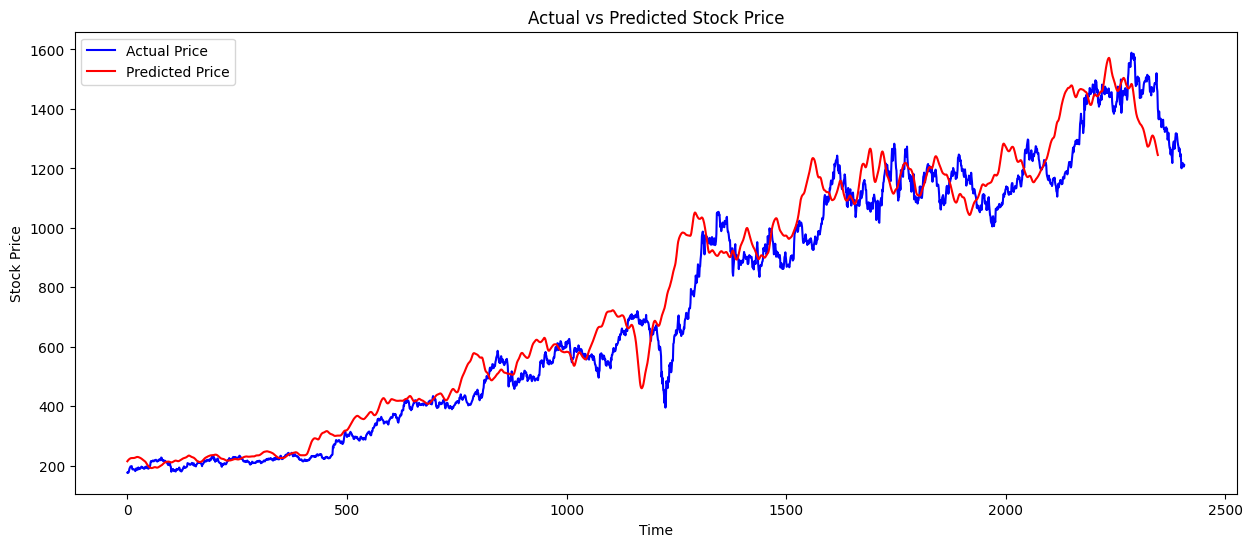

In [31]:
plt.figure(figsize=(15,6))

plt.plot(y_test, color='blue', label='Actual Price')
plt.plot(predicted_prices, color='red', label='Predicted Price')

plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [32]:
from sklearn.metrics import mean_squared_error
import math

In [34]:
x_test = []
y_test = []

for i in range(60, len(scaled_data)):
    x_test.append(scaled_data[i-60:i, 0])
    y_test.append(close_data[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)


In [35]:
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

print(x_test.shape)
print(y_test.shape)

(2407, 60, 1)
(2407,)


In [36]:
predicted_prices = model.predict(x_test)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [37]:
predicted_prices = scaler.inverse_transform(predicted_prices)

In [38]:
rmse = np.sqrt(mean_squared_error(y_test, predicted_prices))

print("RMSE Value:", rmse)

RMSE Value: 30.998135672902986


In [39]:
accuracy = 100 - (rmse / np.mean(y_test) * 100)

print("Model Accuracy:", accuracy, "%")

Model Accuracy: 95.8349859620528 %


In [40]:
data = pd.read_csv("/content/drive/MyDrive/StockMarketPrediction/dataset/reliance_stock_data.csv")

print(data.head())

        Price               Close                High                 Low  \
0      Ticker         RELIANCE.NS         RELIANCE.NS         RELIANCE.NS   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-01   189.9998016357422  190.87715534273178   189.0903506676063   
3  2015-01-02   189.4969482421875  191.74382815812206  189.22947104058622   
4  2015-01-05  187.42124938964844  190.64177456827719  187.04676706013433   

                 Open       Volume  
0         RELIANCE.NS  RELIANCE.NS  
1                 NaN          NaN  
2  189.65743085018167      2963643  
3  190.04261601795088      7331366  
4   189.3792394487279     10103941  


In [42]:
print(data.columns)

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [43]:
data = pd.read_csv(
    "/content/drive/MyDrive/StockMarketPrediction/dataset/reliance_stock_data.csv",
    index_col=0
)

print(data.head())

                         Close                High                 Low  \
Price                                                                    
Ticker             RELIANCE.NS         RELIANCE.NS         RELIANCE.NS   
Date                       NaN                 NaN                 NaN   
2015-01-01   189.9998016357422  190.87715534273178   189.0903506676063   
2015-01-02   189.4969482421875  191.74382815812206  189.22947104058622   
2015-01-05  187.42124938964844  190.64177456827719  187.04676706013433   

                          Open       Volume  
Price                                        
Ticker             RELIANCE.NS  RELIANCE.NS  
Date                       NaN          NaN  
2015-01-01  189.65743085018167      2963643  
2015-01-02  190.04261601795088      7331366  
2015-01-05   189.3792394487279     10103941  


In [46]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


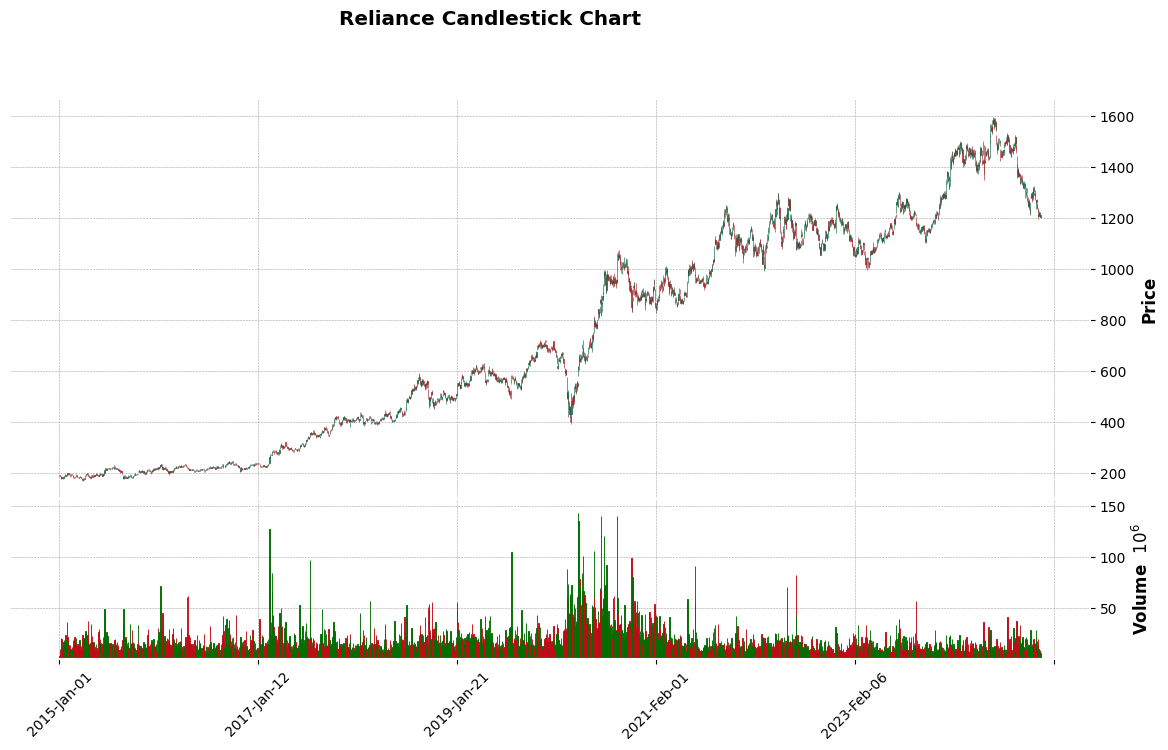

In [2]:
import pandas as pd
import mplfinance as mpf

# Read CSV and skip extra rows
data = pd.read_csv(
    "/content/drive/MyDrive/StockMarketPrediction/dataset/reliance_stock_data.csv",
    skiprows=2
)

# Rename columns properly
data.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Convert Date column
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Remove invalid rows
data = data.dropna(subset=['Date'])

# Set Date as index
data.set_index('Date', inplace=True)

# Convert columns to numeric
columns = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove empty values
data = data.dropna()

# Plot Candlestick Chart
mpf.plot(
    data,
    type='candle',
    volume=True,
    style='charles',
    title='Reliance Candlestick Chart',
    figsize=(15,8)
)

In [3]:
# 50-day Moving Average
data['MA50'] = data['Close'].rolling(window=50).mean()

# 200-day Moving Average
data['MA200'] = data['Close'].rolling(window=200).mean()

print(data[['Close', 'MA50', 'MA200']].tail())

                  Close         MA50        MA200
Date                                             
2024-12-24  1217.885864  1291.424678  1422.583533
2024-12-26  1211.710571  1288.317588  1421.236275
2024-12-27  1216.192749  1285.867874  1419.835613
2024-12-30  1205.883789  1283.011780  1418.419142
2024-12-31  1210.614868  1280.203494  1417.012430


In [4]:
data['Signal'] = 0

# Buy Signal
data.loc[data['MA50'] > data['MA200'], 'Signal'] = 1

# Sell Signal
data.loc[data['MA50'] < data['MA200'], 'Signal'] = -1

print(data[['Close', 'MA50', 'MA200', 'Signal']].tail())

                  Close         MA50        MA200  Signal
Date                                                     
2024-12-24  1217.885864  1291.424678  1422.583533      -1
2024-12-26  1211.710571  1288.317588  1421.236275      -1
2024-12-27  1216.192749  1285.867874  1419.835613      -1
2024-12-30  1205.883789  1283.011780  1418.419142      -1
2024-12-31  1210.614868  1280.203494  1417.012430      -1


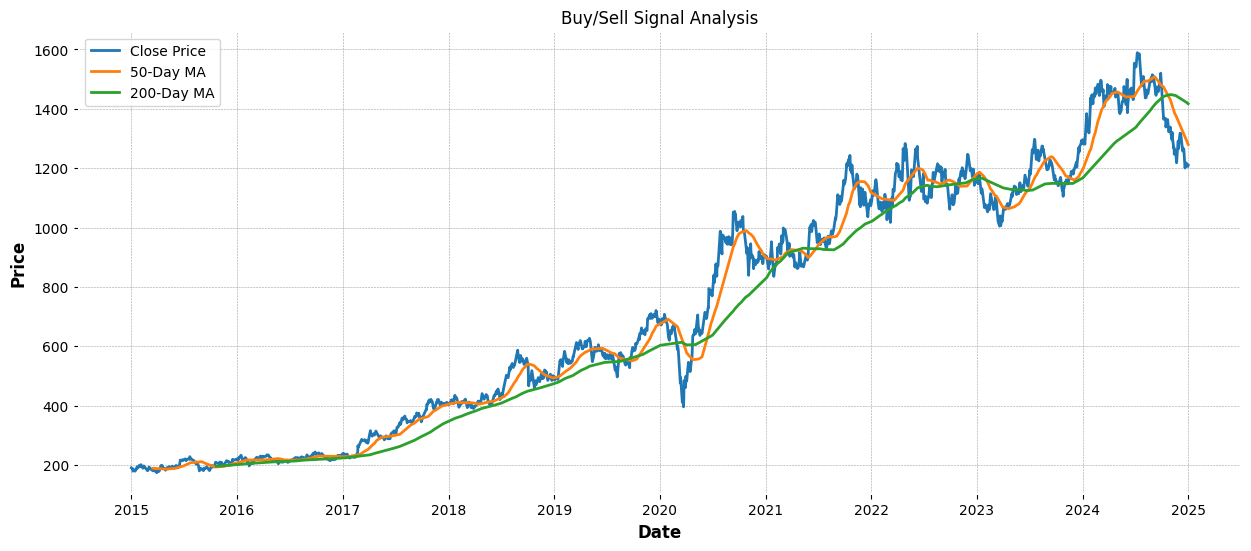

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA50'], label='50-Day MA')
plt.plot(data['MA200'], label='200-Day MA')

plt.title("Buy/Sell Signal Analysis")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [6]:
from textblob import TextBlob

In [7]:
news_headlines = [
    "Reliance stock rises after strong quarterly profits",
    "Market crashes due to global recession fears",
    "Investors optimistic about Reliance future growth",
    "Company faces heavy losses in telecom sector",
    "Reliance announces major expansion plans"
]

In [8]:
for news in news_headlines:

    analysis = TextBlob(news)

    sentiment = analysis.sentiment.polarity

    if sentiment > 0:
        result = "Positive"
    elif sentiment < 0:
        result = "Negative"
    else:
        result = "Neutral"

    print("News:", news)
    print("Sentiment:", result)
    print("Polarity Score:", sentiment)
    print("----------------------")

News: Reliance stock rises after strong quarterly profits
Sentiment: Positive
Polarity Score: 0.43333333333333335
----------------------
News: Market crashes due to global recession fears
Sentiment: Negative
Polarity Score: -0.0625
----------------------
News: Investors optimistic about Reliance future growth
Sentiment: Neutral
Polarity Score: 0.0
----------------------
News: Company faces heavy losses in telecom sector
Sentiment: Negative
Polarity Score: -0.2
----------------------
News: Reliance announces major expansion plans
Sentiment: Positive
Polarity Score: 0.0625
----------------------
